## 📘 Central Limit Theorem & Chi-Square — Simple Answers

---

### ✅ 1. What does the Central Limit Theorem (CLT) state in simple words?

The Central Limit Theorem says:

When we repeatedly take samples from any population and calculate their means, the distribution of those means becomes approximately **normal (bell-shaped)** — even if the original population is not normal — provided the sample size is large enough.

In simple words:

- Larger samples → normal distribution of averages  
- Makes statistical analysis easier  

---

### ✅ 2. Why is CLT important in inferential statistics?

CLT is important because it:

- Allows us to assume normality for sample means  
- Helps build confidence intervals  
- Enables hypothesis testing  
- Works even when population distribution is unknown  

Without CLT, many statistical methods would not be reliable.

---

### ✅ 3. What happens to the sampling distribution when sample size increases?

As sample size increases:

- Distribution becomes more normal  
- Spread (standard error) decreases  
- Estimates become more accurate  
- Results become more stable  

Larger samples give better population representation.

---

### ✅ 4. Why is sample size ≥ 30 often recommended?

A sample size of 30 or more is recommended because:

- CLT begins to hold well  
- Sampling distribution becomes nearly normal  
- Reduces variability and error  

This is a guideline, not a strict rule.

---

### ✅ 5. When do we use the Chi-Square Test?

The Chi-Square test is used when:

- Data is categorical  
- Comparing observed vs expected frequencies  
- Testing relationships between variables  

Common uses include fairness testing, surveys, and independence testing.

---

### ✅ 6. Difference between Goodness of Fit & Test of Independence

| Feature | Goodness of Fit Test | Test of Independence |
|---------|---------------------|----------------------|
| Purpose | Compare observed data with expected distribution | Check relationship between two variables |
| Variables | One categorical variable | Two categorical variables |
| Goal | Does data match expectation? | Are variables related? |

---

### ✅ 7. Degrees of Freedom Calculation

#### Goodness of Fit

df = number of categories − 1

#### Independence Test

df = (rows − 1) × (columns − 1)

---

### ✅ 8. Why is Chi-Square always right-tailed?

Chi-Square is right-tailed because:

- Values are always positive  
- Based on squared differences  
- Larger values indicate greater deviation  
- Rejection region lies on the right side  

We only care about large deviations.

---


# Question 1: Central Limit Theorem (CLT)

### 📘 Scenario

#### An e-commerce company has highly skewed order values.

- **You are given:** \
• Population mean = ₹2000 \
• Population standard deviation = ₹800

- You take a sample of size n = 40.

---

### 📝 Tasks
#### State the Central Limit Theorem.
- **Calculate:**
- Standard Error
- Find probability that sample mean exceeds ₹2200.
- Interpret the result in business context.
- Simulate sampling distribution using Python.
- Plot histogram of sample means.
- Explain why distribution looks normal even if population is skewed.

Standard Error: 126.49110640673517
Z-score: 1.5811388300841898
Probability mean > 2200: 0.056923149003329065


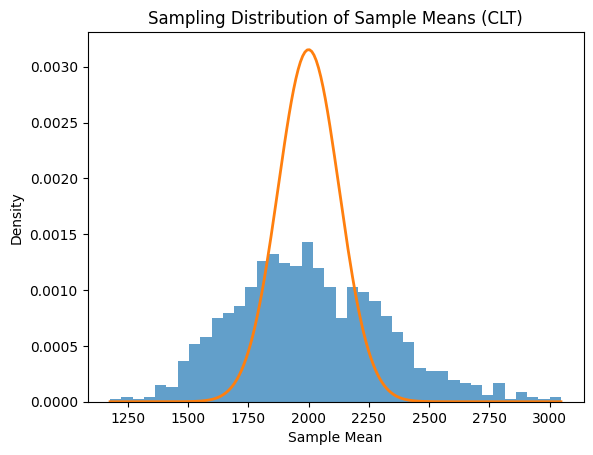

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 2000         
sigma = 800       
n = 40   
num_samples = 1000

population = np.random.exponential(scale=mu, size=100000)
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, n)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

SE = sigma / np.sqrt(n)
print("Standard Error:", SE)

z = (2200 - mu) / SE
prob = 1 - norm.cdf(z)

print("Z-score:", z)
print("Probability mean > 2200:", prob)

plt.hist(sample_means, bins=40, density=True, alpha=0.7)
x = np.linspace(min(sample_means), max(sample_means), 200)
plt.plot(x, norm.pdf(x, mu, SE), linewidth=2) 
plt.title("Sampling Distribution of Sample Means (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Density") 
plt.show()

# Question 2: Chi-Square Test (Goodness of Fit)

### 📘 Scenario
#### A telecom company claims that customer complaints are distributed as:
| Category | Expected % |
|----------|------------|
| Network  | 50% |
| Billing  | 30% |
| Service  | 20% |

From **300 complaints**, the observed counts are:

| Category | Observed |
|----------|----------|
| Network  | 120 |
| Billing  | 110 |
| Service  | 70 |

Test the claim at **α = 0.05**.
---

## 📝 Tasks
- State H₀ and H₁.
- Calculate expected frequencies.
- Compute Chi-Square statistic manually.
- Find degrees of freedom.
- Compute p-value.
- Find critical Chi-Square value.
- Make decision using:
- Method-1 (p-value comparison)
- Method-2 (critical value comparison)
- Interpret result in plain English.

In [10]:
import numpy as np
from scipy.stats import chi2

categories = ["Network", "Billing", "Service"]

observed = np.array([120, 110, 70])
expected_percent = np.array([0.50, 0.30, 0.20])
total = 300
alpha = 0.05

print("\nH0: Complaint distribution matches company claim")
print("H1: Complaint distribution does NOT match company claim")

expected = expected_percent * total

print("\nExpected Frequencies:")
for c, e in zip(categories, expected):
    print(f"{c}: {e}") 
 
chi_square = np.sum((observed - expected) ** 2 / expected)

print("\nChi-Square Statistic:", chi_square)

df = len(categories) - 1
print("Degrees of Freedom:", df)

p_value = 1 - chi2.cdf(chi_square, df)
print("p-value:", p_value)
critical_value = chi2.ppf(1 - alpha, df)
print("Critical Chi-Square Value:", critical_value)

print("\nDecision (Method 1: p-value comparison)")
if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

print("\nDecision (Method 2: critical value comparison)")
if chi_square > critical_value:
    print("Reject H0")
else:
    print("Fail to Reject H0")

print("\nInterpretation:")
print("There is sufficient evidence to conclude that the complaint")
print("distribution differs from the company's claim.")



H0: Complaint distribution matches company claim
H1: Complaint distribution does NOT match company claim

Expected Frequencies:
Network: 150.0
Billing: 90.0
Service: 60.0

Chi-Square Statistic: 12.11111111111111
Degrees of Freedom: 2
p-value: 0.002344799092590777
Critical Chi-Square Value: 5.991464547107979

Decision (Method 1: p-value comparison)
Reject H0

Decision (Method 2: critical value comparison)
Reject H0

Interpretation:
There is sufficient evidence to conclude that the complaint
distribution differs from the company's claim.


# Question 3: Chi-Square Test of Independence

---

## 📘 Scenario

A survey checks whether **Device Type** affects **Subscription Plan**.

| Device Type | Basic | Premium |
|-------------|-------|---------|
| Android | 80 | 40 |
| iOS | 60 | 70 |

Test whether subscription plan depends on device type at **α = 0.05**.

---

## 📝 Tasks

- State **H₀** and **H₁**  
- Compute expected frequencies  
- Calculate Chi-Square statistic  
- Compute degrees of freedom  
- Find p-value  
- Compute critical value  
- Apply BOTH decision methods  
- Interpret association in business language  

---


In [23]:
import numpy as np 
from scipy.stats import chi2_contingency, chi2

print("H0: Device type and subscription plan are independent.")
print("H1: Device type and subscription plan are dependent.")

observed = np.array([
    [80, 40],
    [60,70]
])

alpha = 0.05
print("Observed Frequency Tables : \n" ,observed)
chi_stat, p_value, df,expected = chi2_contingency(observed)
print("\nExpected Frequencies:\n", expected)
print("\nChi-Square Statistic:", chi_stat)
print("Degrees of Freedom:", df)
print("p-value:", p_value)

critical = chi2.ppf(1  - alpha, df)
print("Critical Value : ",critical_value)

print("\nDecision (Method 1 - P-value) : ")
if p_value < alpha : 
    print("Reject H0")
else :
    print("Fail to Reject H0")

print("\nDecision (Method 2 - Critical Value)")

if chi_stat > critical_value : 
    print("Reject H0")
else : 
    print("Fail to Reject H0")

print("\nInterpretation:")
print("Subscription plan choice is associated with device type.")

H0: Device type and subscription plan are independent.
H1: Device type and subscription plan are dependent.
Observed Frequency Tables : 
 [[80 40]
 [60 70]]

Expected Frequencies:
 [[67.2 52.8]
 [72.8 57.2]]

Chi-Square Statistic: 9.839769605394602
Degrees of Freedom: 1
p-value: 0.0017077888624378302
Critical Value :  5.991464547107979

Decision (Method 1 - P-value) : 
Reject H0

Decision (Method 2 - Critical Value)
Reject H0

Interpretation:
Subscription plan choice is associated with device type.
